# ML Theory for Software Engineers

This notebook walks through core machine-learning concepts using **scikit-learn**, **pandas**, and **matplotlib/seaborn**.

We use the classic **Iris flower dataset** — 150 samples, 4 numeric features, 3 species classes. It is small enough to understand quickly, yet rich enough to demonstrate every topic below.

**Topics covered:**
1. X, y, and ŷ (predictions)
2. Train / validation / test splits
3. X_train, y_train, X_test, y_test
4. Randomized sampling (shuffling)
5. Hyperparameter tuning (5-fold CV, grid search, Bayesian search)
6. Overfitting and underfitting
7. Bias–variance trade-off
8. IID assumption (why shuffling matters)
9. Confusion matrix
10. Classification metrics (accuracy, precision, recall, F1)


## Prerequisites & environment setup

Run this lab from the **repository root** (`mlcon/`) locally, or from **`/app`** inside the Docker container. You need **Python 3.12+** locally (Homebrew or python.org — not the broken system Jupyter on macOS). The Docker image uses Python 3.9 with the same core lab packages.

### One-time setup (local)

From the repo root, create a virtual environment and install dependencies:

```bash
cd /path/to/mlcon
python3.12 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```

> **Why a venv?** macOS Homebrew Python blocks global `pip install` (PEP 668). A venv keeps all lab packages isolated in `.venv/`.

### Before each terminal session (local)

Activate the venv whenever you open a new terminal:

```bash
cd /path/to/mlcon
source .venv/bin/activate
```

Your prompt should show `(.venv)`.

### Docker (alternative)

From the repo root on your **host** machine:

```bash
docker build -t aikurs-container .
docker run -it --rm -v $(pwd):/app -p 8888:8888 -p 5050:5050 -p 5001:5001 aikurs-container bash
```

Inside the container:

```bash
cd /app
jupyter lab --ip=0.0.0.0 --port=8888 --no-browser --allow-root
```

Open the Jupyter URL on your host (port **8888**). No extra setup is needed — all cells run in the container kernel.

### In VS Code / Jupyter

Select the kernel **`.venv`** or interpreter **`.venv/bin/python`** (top-right of the notebook). Then run the **Setup** cell below.

### Packages used in this lab

| Package | Purpose |
|---------|---------|
| `scikit-learn` | Models, metrics, Iris dataset, train/test splits |
| `scikit-optimize` | Bayesian hyperparameter search (`BayesSearchCV`) |
| `pandas` | DataFrames for readable tables |
| `matplotlib` / `seaborn` | Plots and confusion-matrix heatmaps |
| `numpy` | Arrays behind X and y |

## Setup

Import libraries and configure plotting. Run this cell first before continuing through the notebook.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve,
)
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

print("Libraries loaded. Random seed =", RANDOM_STATE)


Libraries loaded. Random seed = 42


---
## 1. Data, Labels, and Features - X, y, and ŷ

In supervised learning we always distinguish three objects:

| Symbol | Name | Meaning |
|--------|------|--------|
| **X** | Features (inputs) | A matrix of observations — each row is one sample, each column is one feature |
| **y** | Target (labels) | The ground-truth answer we want the model to learn |
| **ŷ** (y-hat) | Predictions | What the trained model outputs for unseen X |

Think of it like a function: the model learns `f` such that `ŷ = f(X)` and we want `ŷ ≈ y`.


In [2]:
# Load Iris dataset from sklearn
iris = load_iris()

# X: feature matrix (150 rows × 4 columns)
X = iris.data
# y: target vector (150 labels: 0, 1, or 2)
y = iris.target

# Wrap in a DataFrame for readability
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in y]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print()
df.head()


Shape of X: (150, 4)
Shape of y: (150,)



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Train a simple model on ALL data (educational only — never evaluate on training data!)
model_demo = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
model_demo.fit(X, y)

# ŷ = model predictions
y_hat = model_demo.predict(X)

print("First 10 true labels (y):      ", y[:10])
print("First 10 predictions (ŷ):      ", y_hat[:10])
print()
print("Number of correct predictions:", (y_hat == y).sum(), "/", len(y))


First 10 true labels (y):       [0 0 0 0 0 0 0 0 0 0]
First 10 predictions (ŷ):       [0 0 0 0 0 0 0 0 0 0]

Number of correct predictions: 146 / 150


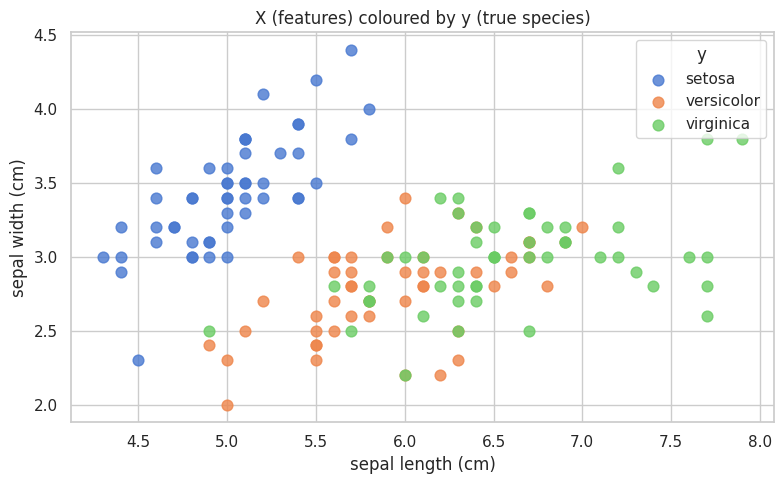

In [4]:
# Visualise X (two features) coloured by y
fig, ax = plt.subplots()
for species_id, species_name in enumerate(iris.target_names):
    mask = y == species_id
    ax.scatter(X[mask, 0], X[mask, 1], label=species_name, s=60, alpha=0.8)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_title("X (features) coloured by y (true species)")
ax.legend(title="y")
plt.tight_layout()
plt.show()


---
## 2. Train, Validation, and Test Split

We never evaluate a model on the same data it was trained on — that would be **cheating** (the model has already seen the answers).

| Set | Purpose |
|-----|--------|
| **Training set** | The model learns patterns from this data (`model.fit`) |
| **Validation set** | Used to compare models / tune hyperparameters without touching the test set |
| **Test set** | Final, unbiased estimate of real-world performance — used **once** at the end |

Typical split: 60 % train · 20 % validation · 20 % test (ratios vary by dataset size).


In [5]:
# Step 1: separate test set (20 %)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Step 2: split remaining 80 % into train (75 % of temp → 60 % overall) and val (25 % of temp → 20 % overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

total = len(y)
print(f"Total samples:     {total}")
print(f"Training set:      {len(y_train):4d}  ({len(y_train)/total:.0%})")
print(f"Validation set:    {len(y_val):4d}  ({len(y_val)/total:.0%})")
print(f"Test set:          {len(y_test):4d}  ({len(y_test)/total:.0%})")
print()
print("Class distribution in each split (stratified — same proportions):")
for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = pd.Series(labels).value_counts().sort_index()
    print(f"  {name:5s}: {dict(counts)}")


Total samples:     150
Training set:        90  (60%)
Validation set:      30  (20%)
Test set:            30  (20%)

Class distribution in each split (stratified — same proportions):
  train: {0: np.int64(30), 1: np.int64(30), 2: np.int64(30)}
  val  : {0: np.int64(10), 1: np.int64(10), 2: np.int64(10)}
  test : {0: np.int64(10), 1: np.int64(10), 2: np.int64(10)}


---
## 3. X_train, y_train, X_test, y_test

After splitting, each partition has its own feature matrix and label vector:

```
model.fit(X_train, y_train)       # learn from training data only
y_val_pred  = model.predict(X_val)   # tune / select hyperparameters
y_test_pred = model.predict(X_test)  # final evaluation
```

The naming convention `X_` / `y_` prefix tells you which split you are working with.


In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape)
print("y_test  shape:", y_test.shape)
print()

train_df = pd.DataFrame(X_train, columns=iris.feature_names)
train_df["species_id"] = y_train
print("First 5 training rows:")
display(train_df.head())

test_df = pd.DataFrame(X_test, columns=iris.feature_names)
test_df["species_id"] = y_test
print("First 5 test rows:")
display(test_df.head())


X_train shape: (90, 4)
y_train shape: (90,)
X_test  shape: (30, 4)
y_test  shape: (30,)

First 5 training rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
0,6.7,3.3,5.7,2.1,2
1,5.0,3.5,1.3,0.3,0
2,6.5,2.8,4.6,1.5,1
3,5.1,3.3,1.7,0.5,0
4,6.7,2.5,5.8,1.8,2


First 5 test rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
0,4.4,3.0,1.3,0.2,0
1,6.1,3.0,4.9,1.8,2
2,4.9,2.4,3.3,1.0,1
3,5.0,2.3,3.3,1.0,1
4,4.4,3.2,1.3,0.2,0


In [7]:
# Train on training data, predict on test data
clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

y_test_hat = clf.predict(X_test)

test_results = pd.DataFrame({
    "y_true": y_test,
    "y_hat": y_test_hat,
    "correct": y_test == y_test_hat,
})
test_results["species_true"] = [iris.target_names[i] for i in test_results["y_true"]]
test_results["species_pred"] = [iris.target_names[i] for i in test_results["y_hat"]]

print(f"Test accuracy: {accuracy_score(y_test, y_test_hat):.2%}")
print()
display(test_results)


Test accuracy: 93.33%



,y_true,y_hat,correct,species_true,species_pred
0,0,0,True,setosa,setosa
1,2,2,True,virginica,virginica
2,1,1,True,versicolor,versicolor
3,1,1,True,versicolor,versicolor
4,0,0,True,setosa,setosa
5,1,1,True,versicolor,versicolor
6,0,0,True,setosa,setosa
7,0,0,True,setosa,setosa
8,2,2,True,virginica,virginica
9,1,1,True,versicolor,versicolor


---
## 4. Randomized Sampling (Shuffling)

`train_test_split` shuffles the data **before** splitting (by default `shuffle=True`).

**Why?** If rows are ordered (e.g. all class-0 first, then class-1, then class-2), a naive sequential split puts entire classes into one partition — the model never sees some classes during training.

Below we compare a **shuffled** split vs a **sequential** (no-shuffle) split on ordered data.


In [8]:
# Create an artificially ORDERED dataset: all setosa, then versicolor, then virginica
order = np.argsort(y)  # y is already 0,0,...,1,1,...,2,2,... but let's be explicit
X_ordered = X[order]
y_ordered = y[order]

print("Ordered y (first 15):", y_ordered[:15])
print("Ordered y (last  15):", y_ordered[-15:])


Ordered y (first 15): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Ordered y (last  15): [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [9]:
def split_comparison(X_in, y_in, shuffle, label):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_in, y_in, test_size=0.3, shuffle=shuffle, random_state=RANDOM_STATE
    )
    train_dist = pd.Series(y_tr).value_counts().sort_index()
    test_dist  = pd.Series(y_te).value_counts().sort_index()
    print(f"\n=== {label} (shuffle={shuffle}) ===")
    print(f"  Train class counts: {dict(train_dist)}")
    print(f"  Test  class counts: {dict(test_dist)}")
    missing_in_train = set(range(3)) - set(train_dist.index)
    missing_in_test  = set(range(3)) - set(test_dist.index)
    if missing_in_train:
        print(f"  ⚠ Classes MISSING from train: {missing_in_train}")
    if missing_in_test:
        print(f"  ⚠ Classes MISSING from test:  {missing_in_test}")
    return y_tr, y_te

y_tr_seq, y_te_seq = split_comparison(X_ordered, y_ordered, shuffle=False, label="Sequential split")
y_tr_shuf, y_te_shuf = split_comparison(X_ordered, y_ordered, shuffle=True, label="Shuffled split")



=== Sequential split (shuffle=False) ===
  Train class counts: {0: np.int64(50), 1: np.int64(50), 2: np.int64(5)}
  Test  class counts: {2: np.int64(45)}
  ⚠ Classes MISSING from test:  {0, 1}

=== Shuffled split (shuffle=True) ===
  Train class counts: {0: np.int64(31), 1: np.int64(37), 2: np.int64(37)}
  Test  class counts: {0: np.int64(19), 1: np.int64(13), 2: np.int64(13)}


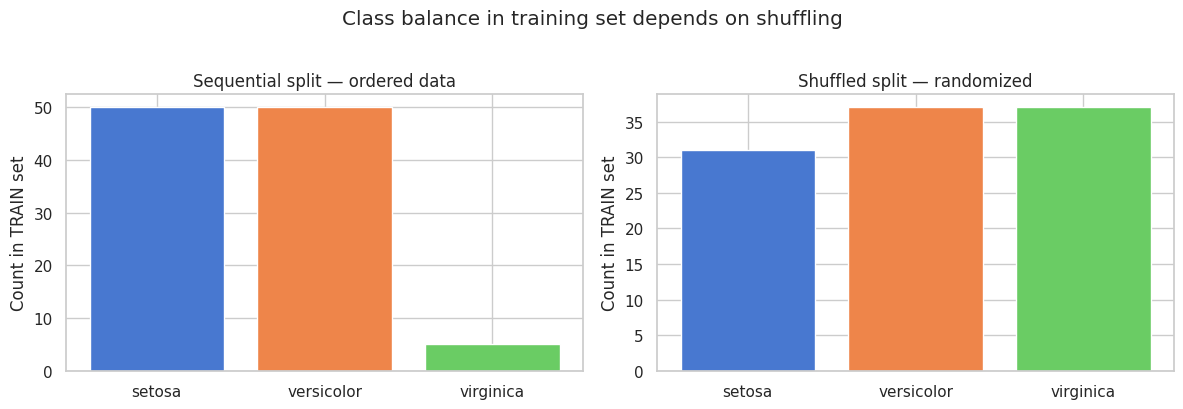

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_tr, title in [
    (axes[0], y_tr_seq, "Sequential split — ordered data"),
    (axes[1], y_tr_shuf, "Shuffled split — randomized"),
]:
    counts = pd.Series(y_tr).value_counts().sort_index()
    ax.bar([iris.target_names[i] for i in counts.index], counts.values, color=sns.color_palette("muted", 3))
    ax.set_title(title)
    ax.set_ylabel("Count in TRAIN set")

plt.suptitle("Class balance in training set depends on shuffling", y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Hyperparameter Tuning

**Parameters** are learned from data (e.g. tree split thresholds).
**Hyperparameters** are set *before* training (e.g. `max_depth`, `min_samples_leaf`).

We tune hyperparameters without touching the **test set**. Two common tools:

| Method | How it searches | Best when |
|--------|-----------------|-----------|
| **Grid search** | Tries *every* combination in a small grid | Few discrete values, you want exhaustive comparison |
| **Bayesian search** | Uses past CV scores to pick the *next* trial intelligently | Same budget as random search, often finds better params faster |

Both methods use **cross-validation** (below) to score each combination on training data only.


### 5.1 Five-Fold Cross-Validation

A single train/validation split can be **lucky or unlucky** depending on which rows land in each set.

**K-fold cross-validation** (here **K = 5**) reuses the training data more reliably:

1. Split `X_train` into 5 equal folds (stratified — each fold keeps the same class mix).
2. For each fold *i*: train on the other 4 folds, score on fold *i*.
3. Report the **mean** (and std) of the 5 scores.

```
Fold 1: [val | train | train | train | train]
Fold 2: [train | val | train | train | train]
...
Fold 5: [train | train | train | train | val]
```

Every training sample is used for both training and validation — just not in the same pass. `GridSearchCV` and `BayesSearchCV` wrap this loop automatically (`cv=5`).

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)

fold_scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring="accuracy")

print("5-fold CV accuracy per fold:", [f"{s:.2%}" for s in fold_scores])
print(f"Mean CV accuracy: {fold_scores.mean():.2%}  (std: {fold_scores.std():.2%})")
print(f"Hold-out validation accuracy (same model): {baseline.fit(X_train, y_train).score(X_val, y_val):.2%}")

5-fold CV accuracy per fold: ['100.00%', '100.00%', '94.44%', '94.44%', '100.00%']
Mean CV accuracy: 97.78%  (std: 2.72%)
Hold-out validation accuracy (same model): 90.00%


### 5.2 Grid Search — exhaustive but slow at scale

`GridSearchCV` tries **every** combination in `param_grid`. With 6 `max_depth` values × 4 `min_samples_leaf` values = **24 models**, each scored with 5-fold CV → **120 fits**.

Fine for small grids; impractical when you have dozens of hyperparameters or continuous ranges.

In [12]:
param_grid = {
    "max_depth": [1, 2, 3, 4, 5, None],
    "min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,                    # 5-fold cross-validation on training data
    scoring="accuracy",
    return_train_score=True,
)
grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Best cross-validated accuracy: {grid.best_score_:.2%}")
print(f"Validation set accuracy: {grid.score(X_val, y_val):.2%}")


Best hyperparameters: {'max_depth': 2, 'min_samples_leaf': 1}
Best cross-validated accuracy: 98.89%
Validation set accuracy: 90.00%


In [13]:
# Show top 5 parameter combinations
results = pd.DataFrame(grid.cv_results_)
cols = ["param_max_depth", "param_min_samples_leaf", "mean_test_score", "std_test_score", "mean_train_score"]
top = results[cols].sort_values("mean_test_score", ascending=False).head(8)
top.columns = ["max_depth", "min_samples_leaf", "cv_val_acc", "cv_std", "cv_train_acc"]
print("Top hyperparameter combinations (cross-validation):")
display(top.round(3))


Top hyperparameter combinations (cross-validation):


,max_depth,min_samples_leaf,cv_val_acc,cv_std,cv_train_acc
12,4,1,0.989,0.022,1.000
13,4,2,0.989,0.022,0.989
22,None,5,0.989,0.022,0.989
21,None,2,0.989,0.022,0.989
20,None,1,0.989,0.022,1.000
19,5,10,0.989,0.022,0.989
18,5,5,0.989,0.022,0.989
17,5,2,0.989,0.022,0.989


### 5.3 Bayesian Search — smarter than random guessing

`BayesSearchCV` (from **scikit-optimize**) still runs only **`n_iter` trials**, but each new trial is chosen using **past cross-validation scores**. A surrogate model estimates which hyperparameters are likely to improve the score, so trials concentrate in promising regions instead of being uniformly random.

Compared to grid search on a large space, Bayesian search typically reaches good hyperparameters in **far fewer fits** — a common choice in production when tuning is expensive.

In [14]:
search_spaces = {
    "max_depth": Categorical([1, 2, 3, 4, 5, 6, 7, 8, None]),
    "min_samples_leaf": Integer(1, 20),
    "min_samples_split": Integer(2, 30),
}

N_ITER = 30

bayes_search = BayesSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    search_spaces,
    n_iter=N_ITER,
    cv=5,
    scoring="accuracy",
    random_state=RANDOM_STATE,
)
bayes_search.fit(X_train, y_train)

grid_combos = len(grid.cv_results_["params"])
print(f"GridSearchCV:  {grid_combos} combinations × 5 folds = {grid_combos * 5} fits")
print(f"BayesSearchCV: {N_ITER} guided trials × 5 folds = {N_ITER * 5} fits")
print()
print("Best hyperparameters (Bayesian search):", dict(bayes_search.best_params_))
print(f"Best cross-validated accuracy: {bayes_search.best_score_:.2%}")
print(f"Validation set accuracy: {bayes_search.score(X_val, y_val):.2%}")
print(f"Grid search best CV score was: {grid.best_score_:.2%}")

GridSearchCV:  24 combinations × 5 folds = 120 fits
BayesSearchCV: 30 guided trials × 5 folds = 150 fits

Best hyperparameters (Bayesian search): {'max_depth': 4, 'min_samples_leaf': 15, 'min_samples_split': 28}
Best cross-validated accuracy: 98.89%
Validation set accuracy: 90.00%
Grid search best CV score was: 98.89%


---
## 6. Overfitting and Underfitting

| Problem | Symptom | Cause |
|---------|---------|-------|
| **Underfitting** | High error on train **and** test | Model too simple (high bias) |
| **Overfitting** | Low error on train, high error on test | Model too complex (high variance) |
| **Good fit** | Low error on both | Right complexity |

For a Decision Tree, `max_depth` controls complexity: depth 1 = stump (underfit), depth 20 = memorises noise (overfit).


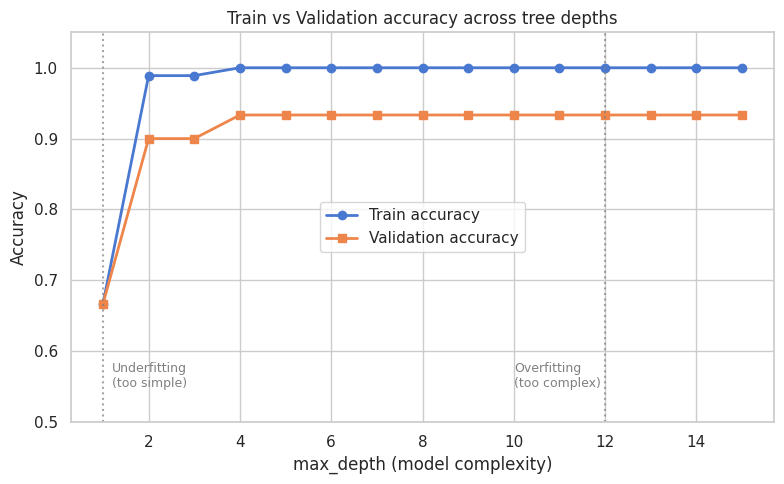

Best validation accuracy at max_depth=4: 93.33%
At max_depth=1  — train: 66.67%, val: 66.67%  → underfitting
At max_depth=15 — train: 100.00%, val: 93.33%  → overfitting


In [15]:
depths = range(1, 16)
train_scores, val_scores = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))
    val_scores.append(accuracy_score(y_val, tree.predict(X_val)))

fig, ax = plt.subplots()
ax.plot(depths, train_scores, "o-", label="Train accuracy", linewidth=2)
ax.plot(depths, val_scores, "s-", label="Validation accuracy", linewidth=2)
ax.axvline(1, color="gray", linestyle=":", alpha=0.7)
ax.text(1.2, 0.55, "Underfitting\n(too simple)", fontsize=9, color="gray")
ax.axvline(12, color="gray", linestyle=":", alpha=0.7)
ax.text(10, 0.55, "Overfitting\n(too complex)", fontsize=9, color="gray")
ax.set_xlabel("max_depth (model complexity)")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Validation accuracy across tree depths")
ax.legend()
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(val_scores)]
print(f"Best validation accuracy at max_depth={best_depth}: {max(val_scores):.2%}")
print(f"At max_depth=1  — train: {train_scores[0]:.2%}, val: {val_scores[0]:.2%}  → underfitting")
print(f"At max_depth=15 — train: {train_scores[-1]:.2%}, val: {val_scores[-1]:.2%}  → overfitting")


---
## 7. Bias–Variance Trade-off

Total prediction error decomposes into:

```
Error = Bias² + Variance + Irreducible Noise
```

- **Bias**: systematic error from overly simple assumptions (underfitting)
- **Variance**: sensitivity to training data fluctuations (overfitting)
- As model complexity ↑, bias ↓ but variance ↑ — the sweet spot minimises total error

We approximate this by plotting **training error** (proxy for bias) and **validation error** (proxy for generalisation) vs complexity.


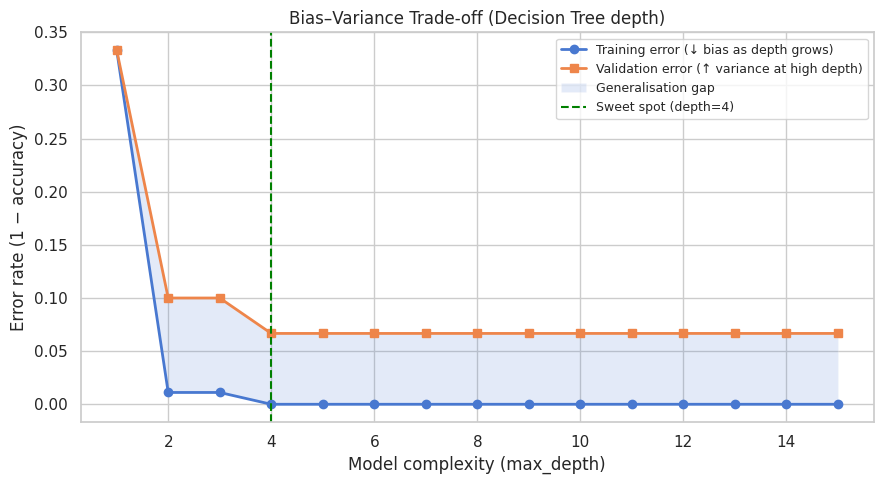

At low depth:  high bias (underfitting) — both errors are high
At high depth: low bias but high variance — train error drops, val error rises
Sweet spot at depth=4 minimises validation error


In [16]:
train_errors = [1 - s for s in train_scores]
val_errors   = [1 - s for s in val_scores]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_errors, "o-", label="Training error (↓ bias as depth grows)", linewidth=2)
ax.plot(depths, val_errors, "s-", label="Validation error (↑ variance at high depth)", linewidth=2)
ax.fill_between(depths, train_errors, val_errors, alpha=0.15, label="Generalisation gap")
best_idx = np.argmin(val_errors)
ax.axvline(depths[best_idx], color="green", linestyle="--", label=f"Sweet spot (depth={depths[best_idx]})")
ax.set_xlabel("Model complexity (max_depth)")
ax.set_ylabel("Error rate (1 − accuracy)")
ax.set_title("Bias–Variance Trade-off (Decision Tree depth)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("At low depth:  high bias (underfitting) — both errors are high")
print("At high depth: low bias but high variance — train error drops, val error rises")
print(f"Sweet spot at depth={depths[best_idx]} minimises validation error")


---
## 8. IID Assumption — Why Independent, Identically Distributed Data Matters

Most ML algorithms assume samples are **Independent and Identically Distributed (IID)**:
- **Independent**: one row does not influence the next
- **Identically distributed**: every row comes from the same underlying process

Real-world data is often **ordered** (time series, sorted logs, sensor streams). If we split without shuffling, train and test sets come from *different regions* of the distribution — leading to misleading evaluation.

Below we simulate a dataset where feature values drift over time (non-IID) and show how train/test distributions diverge when we split sequentially.


In [17]:
np.random.seed(RANDOM_STATE)
n = 300

# Simulate time-ordered sensor readings: feature drifts, target depends on feature
time = np.arange(n)
feature_drift = 0.5 + time / n + np.random.normal(0, 0.05, n)  # drifts from ~0.5 to ~1.5
target = (feature_drift > 1.0).astype(int)  # class flips around the middle

drift_df = pd.DataFrame({"time": time, "feature": feature_drift, "target": target})
print(drift_df.describe())
print()
print("Target rate in first half:  ", drift_df.iloc[:n//2]["target"].mean())
print("Target rate in second half: ", drift_df.iloc[n//2:]["target"].mean())


             time     feature      target
count  300.000000  300.000000  300.000000
mean   149.500000    0.998056    0.510000
std     86.746758    0.296229    0.500735
min      0.000000    0.447669    0.000000
25%     74.750000    0.753320    0.000000
50%    149.500000    1.012020    1.000000
75%    224.250000    1.246395    1.000000
max    299.000000    1.553318    1.000000

Target rate in first half:   0.04666666666666667
Target rate in second half:  0.9733333333333334


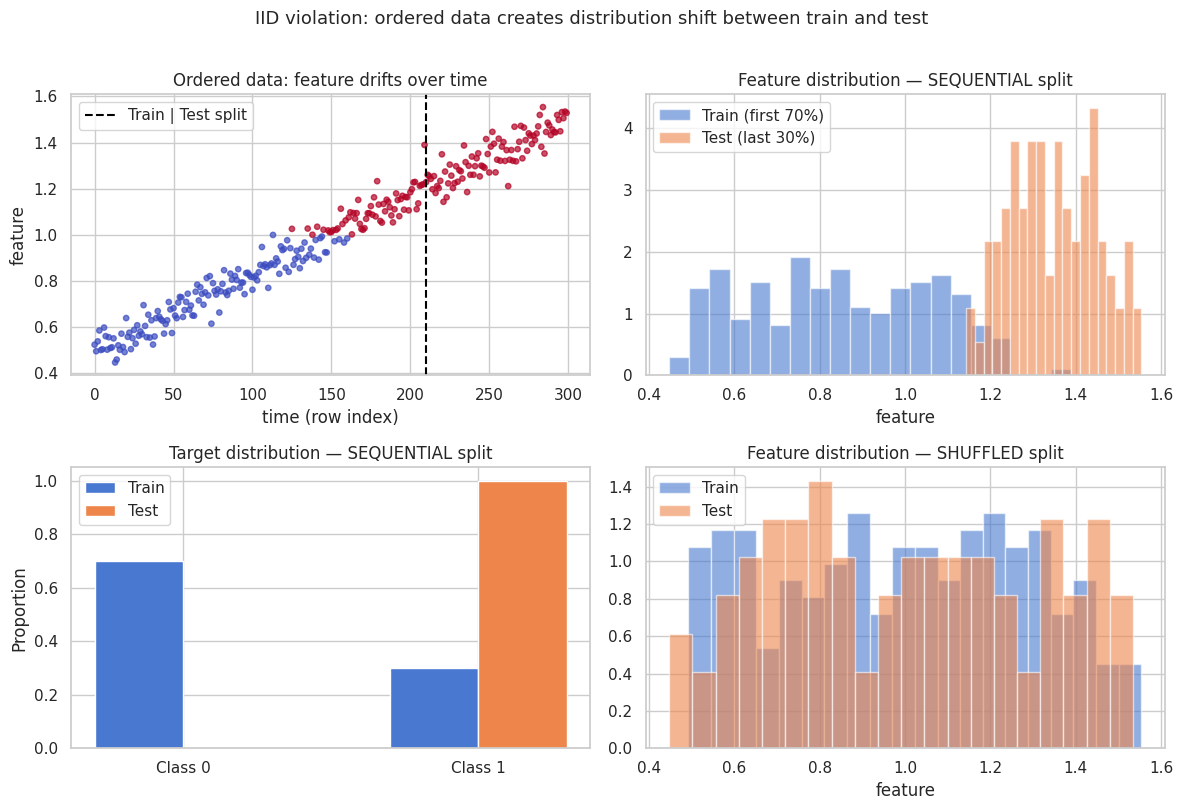

Sequential split — target rate in train: 30.00%
Sequential split — target rate in test:  100.00%
Shuffled split    — target rate in train: 50.95%
Shuffled split    — target rate in test:  51.11%

Takeaway: always understand your data's structure before splitting.
Time-series data needs special splits (e.g. walk-forward), not random shuffle.


In [18]:
# Sequential split (mimics: train on past, test on future — but features have drifted!)
split_point = int(n * 0.7)
train_part = drift_df.iloc[:split_point]
test_part  = drift_df.iloc[split_point:]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Full dataset over time
axes[0, 0].scatter(drift_df["time"], drift_df["feature"], c=drift_df["target"], cmap="coolwarm", s=15, alpha=0.7)
axes[0, 0].axvline(split_point, color="black", linestyle="--", label="Train | Test split")
axes[0, 0].set_title("Ordered data: feature drifts over time")
axes[0, 0].set_xlabel("time (row index)")
axes[0, 0].set_ylabel("feature")
axes[0, 0].legend()

# Feature distribution: train vs test (sequential)
axes[0, 1].hist(train_part["feature"], bins=20, alpha=0.6, label="Train (first 70%)", density=True)
axes[0, 1].hist(test_part["feature"],  bins=20, alpha=0.6, label="Test (last 30%)",  density=True)
axes[0, 1].set_title("Feature distribution — SEQUENTIAL split")
axes[0, 1].set_xlabel("feature")
axes[0, 1].legend()

# Target distribution: train vs test (sequential)
train_tgt = train_part["target"].value_counts(normalize=True).sort_index()
test_tgt  = test_part["target"].value_counts(normalize=True).sort_index()
x_pos = np.arange(2)
axes[1, 0].bar(x_pos - 0.15, [train_tgt.get(0,0), train_tgt.get(1,0)], 0.3, label="Train")
axes[1, 0].bar(x_pos + 0.15, [test_tgt.get(0,0),  test_tgt.get(1,0)],  0.3, label="Test")
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(["Class 0", "Class 1"])
axes[1, 0].set_title("Target distribution — SEQUENTIAL split")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend()

# Shuffled split for comparison
shuffled = drift_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
train_shuf = shuffled.iloc[:split_point]
test_shuf  = shuffled.iloc[split_point:]
axes[1, 1].hist(train_shuf["feature"], bins=20, alpha=0.6, label="Train", density=True)
axes[1, 1].hist(test_shuf["feature"],  bins=20, alpha=0.6, label="Test",  density=True)
axes[1, 1].set_title("Feature distribution — SHUFFLED split")
axes[1, 1].set_xlabel("feature")
axes[1, 1].legend()

plt.suptitle("IID violation: ordered data creates distribution shift between train and test", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("Sequential split — target rate in train:", f"{train_part['target'].mean():.2%}")
print("Sequential split — target rate in test: ", f"{test_part['target'].mean():.2%}")
print("Shuffled split    — target rate in train:", f"{train_shuf['target'].mean():.2%}")
print("Shuffled split    — target rate in test: ", f"{test_shuf['target'].mean():.2%}")
print()
print("Takeaway: always understand your data's structure before splitting.")
print("Time-series data needs special splits (e.g. walk-forward), not random shuffle.")


---
## 9. Confusion Matrix

A confusion matrix compares **true labels** (rows) vs **predicted labels** (columns).

```
                 Predicted
              0    1    2
Actual  0   [TP]  [FP] [FP]
        1   [FN]  [TP] [FP]
        2   [FN]  [FN] [TP]
```

Diagonal = correct predictions. Off-diagonal = mistakes.


Confusion matrix (raw counts):
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]



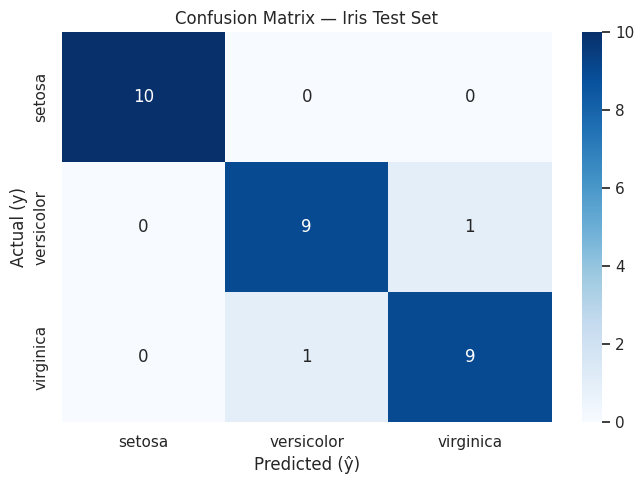

In [19]:
# Use best model from Bayesian search for final evaluation
best_model = bayes_search.best_estimator_
best_model.fit(X_train, y_train)  # refit on train (BayesSearchCV already does this, but explicit is clear)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (raw counts):")
print(cm)
print()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=ax,
)
ax.set_xlabel("Predicted (ŷ)")
ax.set_ylabel("Actual (y)")
ax.set_title("Confusion Matrix — Iris Test Set")
plt.tight_layout()
plt.show()


---
## 10. Classification Metrics

Accuracy alone can be misleading (especially with imbalanced classes). Use multiple metrics:

| Metric | Formula (per class) | Question it answers |
|--------|--------------------|-----------------------|
| **Accuracy** | (TP + TN) / Total | Overall, how often are we right? |
| **Precision** | TP / (TP + FP) | Of predicted positives, how many are correct? |
| **Recall** | TP / (TP + FN) | Of actual positives, how many did we find? |
| **F1-score** | 2 · P · R / (P + R) | Harmonic mean of precision and recall |

- High **precision** → few false alarms (important in spam detection)
- High **recall** → few missed cases (important in disease screening)


In [20]:
print("=" * 60)
print("CLASSIFICATION METRICS — Test Set")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print()

# Per-class and averaged metrics
for avg in ["macro", "weighted"]:
    print(f"--- {avg} average ---")
    print(f"  Precision: {precision_score(y_test, y_pred, average=avg):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred, average=avg):.4f}")
    print(f"  F1-score:  {f1_score(y_test, y_pred, average=avg):.4f}")
    print()

print("--- Per-class breakdown ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


CLASSIFICATION METRICS — Test Set
Accuracy:  0.9333

--- macro average ---
  Precision: 0.9333
  Recall:    0.9333
  F1-score:  0.9333

--- weighted average ---
  Precision: 0.9333
  Recall:    0.9333
  F1-score:  0.9333

--- Per-class breakdown ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [21]:
# Manual calculation for one class (setosa = class 0) to demystify the formulas
class_idx = 0
class_name = iris.target_names[class_idx]
tp = cm[class_idx, class_idx]
fp = cm[:, class_idx].sum() - tp
fn = cm[class_idx, :].sum() - tp
tn = cm.sum() - tp - fp - fn

precision_manual = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_manual    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_manual        = 2 * precision_manual * recall_manual / (precision_manual + recall_manual) if (precision_manual + recall_manual) > 0 else 0

print(f"Manual calculation for class '{class_name}':")
print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"  Precision = TP/(TP+FP) = {tp}/({tp}+{fp}) = {precision_manual:.4f}")
print(f"  Recall    = TP/(TP+FN) = {tp}/({tp}+{fn}) = {recall_manual:.4f}")
print(f"  F1        = 2PR/(P+R)         = {f1_manual:.4f}")
print()
print(f"sklearn agrees: precision={precision_score(y_test, y_pred, average=None)[class_idx]:.4f}, "
      f"recall={recall_score(y_test, y_pred, average=None)[class_idx]:.4f}, "
      f"f1={f1_score(y_test, y_pred, average=None)[class_idx]:.4f}")


Manual calculation for class 'setosa':
  TP=10, FP=0, FN=0, TN=20
  Precision = TP/(TP+FP) = 10/(10+0) = 1.0000
  Recall    = TP/(TP+FN) = 10/(10+0) = 1.0000
  F1        = 2PR/(P+R)         = 1.0000

sklearn agrees: precision=1.0000, recall=1.0000, f1=1.0000


---
## Summary

| Concept | Key takeaway |
|---------|-------------|
| X, y, ŷ | Features, true labels, model predictions |
| Splits | Train to learn, validate to tune, test to evaluate once |
| Shuffling | Prevents class/order leakage between splits |
| Hyperparameters | Tune with 5-fold CV; grid search (exhaustive) or Bayesian search (guided, sample-efficient) |
| Over/underfitting | Watch the gap between train and validation performance |
| Bias–variance | Sweet spot balances simplicity and flexibility |
| IID | Ordered/non-stationary data needs careful splitting |
| Confusion matrix | Shows *where* the model makes mistakes |
| Metrics | Precision, recall, F1 capture different error types |

**Next steps:** try changing the model (`LogisticRegression`, `KNeighborsClassifier`), dataset, or `search_spaces` / `n_iter` in Bayesian search and observe how the metrics change.
